# Operational Screening of Wine Bottling Lots

*MLN601 Assessment 2 - Comparative Classification and CRISP-DM*

Design and Creative Technologies, Torrens University

- **Student:** Luis Guilherme de Barros Andrade Faria - A00187785
- **Subject Name:** Machine Learning
- **Subject Code:** MLN 601
- **Title:** Operational Screening of Wine Bottling Lots (Red + White)
- **Lecturer:** Dr. Kamran Shaukat
- **Assessment No.:** 2
- **Date:** July 2026

| Field | Value |
|---|---|
| Dataset | UCI Wine Quality - red + white combined (Cortez et al., 2009) |
| Target | Low (`quality < 6`) = 1; high (`quality >= 6`) = 0 |
| Required algorithm | Decision Tree, expanded into a nine-family comparison |
| Experiment | Original, fold-only SMOTE and class-weighted training arms |
| Methodology | CRISP-DM |

Each row in the UCI dataset is one laboratory sample. In this project, I treat that single sample as standing in for a whole bottling lot, assuming the lot is homogeneous - I am not classifying individual bottles. The model's job is to flag lots with a higher risk of low sensory quality so the quality-control team can send them for extra tasting or testing. It is a decision-support tool, where a human always makes the final call, and no lot is ever released or rejected automatically.

Quality is a subjective, ordinal score, so every model is framed as a decision-support candidate with post-selection explanation, not a replacement for expert tasting.

## 1. Business Understanding

A wine producer needs to release bottling lots efficiently,  without letting low-quality lots reach distribution. Each row in the dataset is one laboratory-tested wine sample, which here stands for one bottling lot. The business question is: 

> *Can a model flag the lots at higher risk of low sensory quality, so they are sent for extra tasting or testing before release?*

Following the brief, `quality < 6` is considered low (class 1) and `quality >= 6` is considered high (class 0). The model's output is a binary classification, where the positive class (1) indicates a lot that should be sent for extra tasting or testing.

Operationally, a false negative (a low-quality lot classified as high-quality) is more costly than a false positive (a high-quality lot classified as low-quality). The model is therefore a triage layer between laboratory testing and human tasting, and it is designed to be interpretable so that quality-control staff can understand the reasoning behind its predictions and make the final call - the model never releases or rejects a lot on its own.

Success is defined **before modelling**: in five-fold cross-validation (CV), the training data is divided into 5 parts, the model trains on 4 and validates on the 5th, rotating until every part has been used for validation. A candidate must achieve:
- ROC-AUC >= 0.75 - how well a model separates the two classes
- low-quality sensitivity >= 0.70 - how well a test or model finds all the positive cases
- high-quality specificity >= 0.70 - how well a test or model finds all the negative cases

Among candidates passing every gate, balanced accuracy ranks them. A technical tie below 0.01 is resolved by interpretability, followed by simplicity. These are screening targets for this assessment, not validated production service levels.

## 2. Data Understanding

### 2.1 Data acquisition and operational unit

| Item | Detail |
|---|---|
| Source | UCI Machine Learning Repository - Wine Quality (id 186) |
| Link | https://archive.ics.uci.edu/dataset/186/wine+quality |
| Files | `winequality-red.csv` and `winequality-white.csv` |
| Acquisition | Local UCI copies with direct-URL fallback |
| Raw rows | 1,599 red + 4,898 white = 6,497 |
| Operational interpretation | One row stands for one representative lot sample |

The source contains physicochemical tests and an expert sensory score for Portuguese *vinho verde* (Cortez et al., 2009). It has no `batch_id`, production date or release decision, so performance here demonstrates the model's ability to separate low and high quality and technical feasibility, not proven lot-level safety or return on investment. Red and white files are combined with `wine_type` (red = 1, white = 0).

### 2.2 Variables

| Variable group | Type and units | Role |
|---|---|---|
| Fixed, volatile and citric acidity; residual sugar; chlorides; sulphates | Continuous, g/dm3 | Laboratory predictors |
| Free and total sulfur dioxide | Continuous, mg/dm3 | Laboratory predictors |
| Density | Continuous, g/cm3 | Laboratory predictor |
| pH | Continuous, pH scale | Laboratory predictor |
| Alcohol | Continuous, % volume | Laboratory predictor |
| `wine_type` | Engineered binary | Red/white context |
| `quality` | Ordinal integer, source score 0-10 | Source target, excluded from predictors |
| `quality_label` | Engineered binary | Model target: low = 1, high = 0 |

### 2.3 Environment Setup and Data Collection


To keep results reproducible, this section pins the runtime (library versions, RANDOM_STATE = 42) and loads the red and white datasets from a local copy when available, falling back to the UCI repository. A wine_type flag (red = 1, white = 0) is added before combining them into a single dataframe of 6,497 rows.

In [1]:
import os
import sys
import warnings
from importlib.metadata import version as package_version

os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, balanced_accuracy_score,
                             make_scorer)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
except ImportError as exc:
    raise ImportError(
        "Install the Assessment2 requirements first: "
        "python -m pip install -r requirements.txt"
    ) from exc

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

runtime = {
    "Python": sys.version.split()[0],
    "numpy": package_version("numpy"),
    "pandas": package_version("pandas"),
    "scikit-learn": package_version("scikit-learn"),
    "imbalanced-learn": package_version("imbalanced-learn"),
    "shap": package_version("shap"),
}
pd.Series(runtime, name="version").to_frame()

,version
Python,3.14.3
numpy,2.4.6
pandas,3.0.3
scikit-learn,1.9.0
imbalanced-learn,0.14.2
shap,0.52.0


In [2]:
from pathlib import Path

# Resolve folders whether execution starts from notebook/ or the assessment root.
NB_DIR = Path.cwd()
BASE_DIR = NB_DIR.parent if NB_DIR.name == "notebook" else NB_DIR
OUTPUT_DIR = BASE_DIR / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

UCI_BASE = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
            "wine-quality/")


def load_wine(colour):
    fname = "winequality-%s.csv" % colour
    candidates = [BASE_DIR / "dataset" / fname,
                  NB_DIR / "dataset" / fname,
                  NB_DIR / fname]
    local = next((path for path in candidates if path.exists()), None)
    if local is not None:
        print("Loading local dataset:", local.name)
        return pd.read_csv(local, sep=";")
    print("Loading UCI dataset:", fname)
    return pd.read_csv(UCI_BASE + fname, sep=";")


red = load_wine("red")
white = load_wine("white")
red["wine_type"] = 1
white["wine_type"] = 0
df = pd.concat([red, white], ignore_index=True)

print("Red:", red.shape, "| White:", white.shape, "| Combined:", df.shape)
df.head()

Loading local dataset: winequality-red.csv
Loading local dataset: winequality-white.csv
Red: (1599, 13) | White: (4898, 13) | Combined: (6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [5]:
source_features = [
    "fixed acidity", "volatile acidity", "citric acid", "residual sugar",
    "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
    "pH", "sulphates", "alcohol",
]
expected_columns = source_features + ["quality", "wine_type"]
numeric_values = df[expected_columns].to_numpy()
duplicate_rows = int(df.duplicated().sum())

# IQR flags support an explicit outlier decision; they do not automatically imply errors.
q1 = df[source_features].quantile(0.25)
q3 = df[source_features].quantile(0.75)
iqr = q3 - q1
lower_bounds = q1 - 1.5 * iqr
upper_bounds = q3 + 1.5 * iqr
outlier_flags = (df[source_features].lt(lower_bounds) |
                 df[source_features].gt(upper_bounds))
rows_with_iqr_flags = int(outlier_flags.any(axis=1).sum())
outlier_summary = pd.DataFrame({
    "lower_iqr_bound": lower_bounds,
    "upper_iqr_bound": upper_bounds,
    "flagged_values": outlier_flags.sum(),
    "observed_min": df[source_features].min(),
    "observed_max": df[source_features].max(),
}).sort_values("flagged_values", ascending=False)

hard_checks = {
    "Expected schema": list(df.columns) == expected_columns,
    "All columns numeric": all(pd.api.types.is_numeric_dtype(df[c]) for c in expected_columns),
    "No missing values": int(df.isna().sum().sum()) == 0,
    "All values finite": bool(np.isfinite(numeric_values).all()),
    "No negative laboratory values": bool((df[source_features].to_numpy() >= 0).all()),
    "Quality is integer-valued": bool(np.allclose(df["quality"], df["quality"].astype(int))),
    "Quality within documented 0-10 range": bool(df["quality"].between(0, 10).all()),
    "Free SO2 does not exceed total SO2": bool(
        (df["free sulfur dioxide"] <= df["total sulfur dioxide"]).all()
    ),
}
assert all(hard_checks.values()), "A hard data-quality validation failed"

validation_rows = [
    {"check": name, "status": "Pass" if passed else "Fail", "action": "Retain"}
    for name, passed in hard_checks.items()
]
validation_rows.append({
    "check": "Exact duplicate source rows",
    "status": "Issue found: %d" % duplicate_rows,
    "action": "Remove before target engineering and splitting",
})
validation_rows.append({
    "check": "Rows with at least one 1.5-IQR outlier flag",
    "status": "%d (%.1f%%)" % (rows_with_iqr_flags,
                                100 * rows_with_iqr_flags / len(df)),
    "action": "Retain; plausible and not verified as errors",
})
validation_rows.append({
    "check": "Observed quality levels",
    "status": ", ".join(map(str, sorted(df["quality"].unique()))),
    "action": "Retain; levels are inside documented range",
})
data_quality = pd.DataFrame(validation_rows)
data_quality.to_csv(OUTPUT_DIR / "data_quality_v8.csv", index=False)
outlier_summary.to_csv(OUTPUT_DIR / "outlier_summary_v8.csv")

print("Raw rows: %d | exact duplicates: %d" % (len(df), duplicate_rows))

print("\nTable 2.1 - Data-quality validation register")
print("Hard checks all pass; duplicates and IQR flags carry an explicit action.")
data_quality = data_quality.set_index("check")
display(data_quality)

print("\nTable 2.2 - 1.5-IQR flags per source feature")
print("Flag counts with observed ranges; values are plausible, so rows are retained.")
outlier_summary.index.name = "feature"
display(outlier_summary[["flagged_values", "observed_min", "observed_max"]].round(3))

Raw rows: 6497 | exact duplicates: 1177

Table 2.1 - Data-quality validation register
Hard checks all pass; duplicates and IQR flags carry an explicit action.


,status,action
check,,
Expected schema,Pass,Retain
All columns numeric,Pass,Retain
No missing values,Pass,Retain
All values finite,Pass,Retain
No negative laboratory values,Pass,Retain
Quality is integer-valued,Pass,Retain
Quality within documented 0-10 range,Pass,Retain
Free SO2 does not exceed total SO2,Pass,Retain
Exact duplicate source rows,Issue found: 1177,Remove before target engineering and splitting



Table 2.2 - 1.5-IQR flags per source feature
Flag counts with observed ranges; values are plausible, so rows are retained.


,flagged_values,observed_min,observed_max
feature,,,
citric acid,509,0.000,1.660
volatile acidity,377,0.080,1.580
fixed acidity,357,3.800,15.900
chlorides,286,0.009,0.611
sulphates,191,0.220,2.000
residual sugar,118,0.600,65.800
pH,73,2.720,4.010
free sulfur dioxide,62,1.000,289.000
total sulfur dioxide,10,6.000,440.000


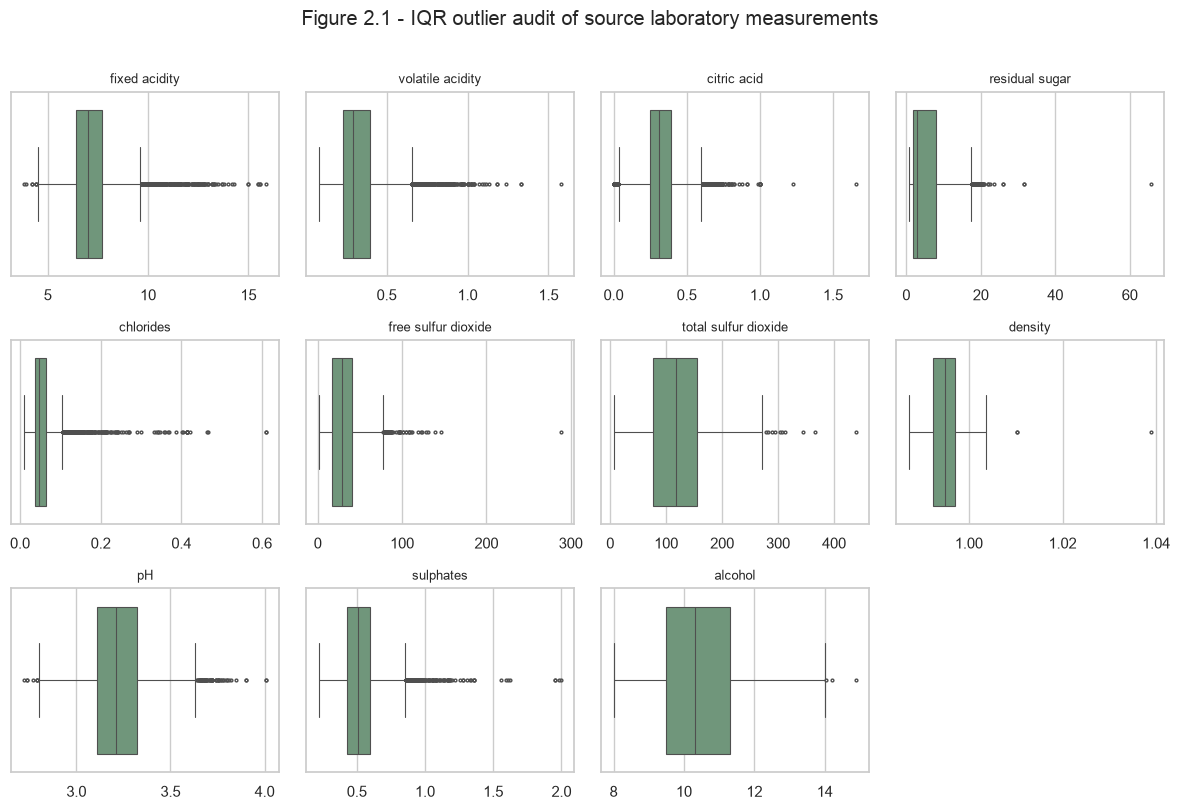

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for ax, feature in zip(axes.flat, source_features):
    sns.boxplot(x=df[feature], ax=ax, color="#6a9c78", fliersize=2,
                linewidth=0.8)
    ax.set_title(feature, fontsize=9)
    ax.set_xlabel("")
for ax in axes.flat[len(source_features):]:
    ax.axis("off")

fig.suptitle("Figure 2.1 - IQR outlier audit of source laboratory measurements", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_outlier_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()

# Note: IQR flags mark values far from the middle 50% of each feature 
# - they're unusual, not wrong. 
# A sweet dessert wine looks like an outlier but is real wine,
# so I keep them and record the decision."

### 2.4 Target definition, duplicates and class balance

The brief's threshold maps `quality < 6` to low (class 1) and `quality >= 6` to high (class 0). Low is the positive class because it is the event that places a lot on review.

The audit finds 1,177 exact duplicate rows. Because UCI provides no sample or lot identifiers, some of these may be genuinely separate samples with identical recorded values. Removing them is a conservative evaluation choice: it prevents the same feature label record from appearing in both training and test data.

The resulting population has 5,320 rows with a moderate class imbalance: 62.6% high against 37.4% low. Section 3 splits this population into training and held-out test sets.

Raw rows: 6497 | duplicates removed: 1177 | unique rows: 5320

Class counts:
quality_label
high (>=6)    3332
low (<6)      1988

Class proportions:
quality_label
high (>=6)    0.626
low (<6)      0.374


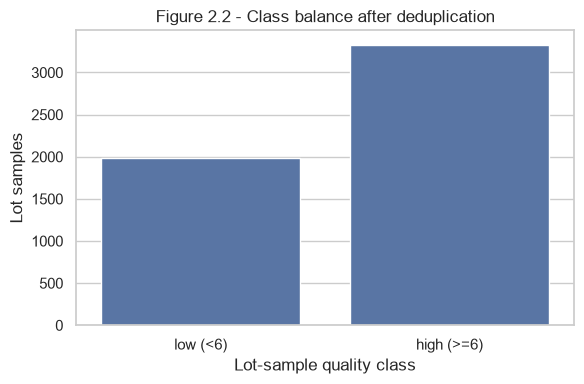

In [7]:
raw_rows = len(df)
duplicate_rows = int(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

df["quality_label"] = (df["quality"] < 6).astype(int)
label_names = {0: "high (>=6)", 1: "low (<6)"}
df["quality_name"] = df["quality_label"].map(label_names)

counts = df["quality_label"].value_counts().sort_index()
print("Raw rows:", raw_rows,
      "| duplicates removed:", duplicate_rows,
      "| unique rows:", len(df))
print("\nClass counts:")
print(counts.rename(index=label_names).to_string())
print("\nClass proportions:")
print((counts / len(df)).round(3).rename(index=label_names).to_string())

plt.figure(figsize=(6, 4))
sns.countplot(x="quality_name", data=df, order=["low (<6)", "high (>=6)"])
plt.title("Figure 2.2 - Class balance after deduplication")
plt.xlabel("Lot-sample quality class")
plt.ylabel("Lot samples")
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_class_balance.png", dpi=120)
plt.show()

### 2.5 Relationships with the target

Three views close the Data Understanding stage:
1. The heatmap shows how the laboraty measurements relate to each other, which flags redudant features.
2. The pairplot shows how much the two classes overlap in feature space, which sets expectations for how hard the classification is.
3. Finally, a correlation ranking against quality_label orders the features by association with the target; since low = 1, a positive value means the feature rises with low quality.

Correlation here is a univariate hint, not causation and not model importance: the tree can rank features differently (*in Section 5 we'll see it does*) once interactions are taken into account.

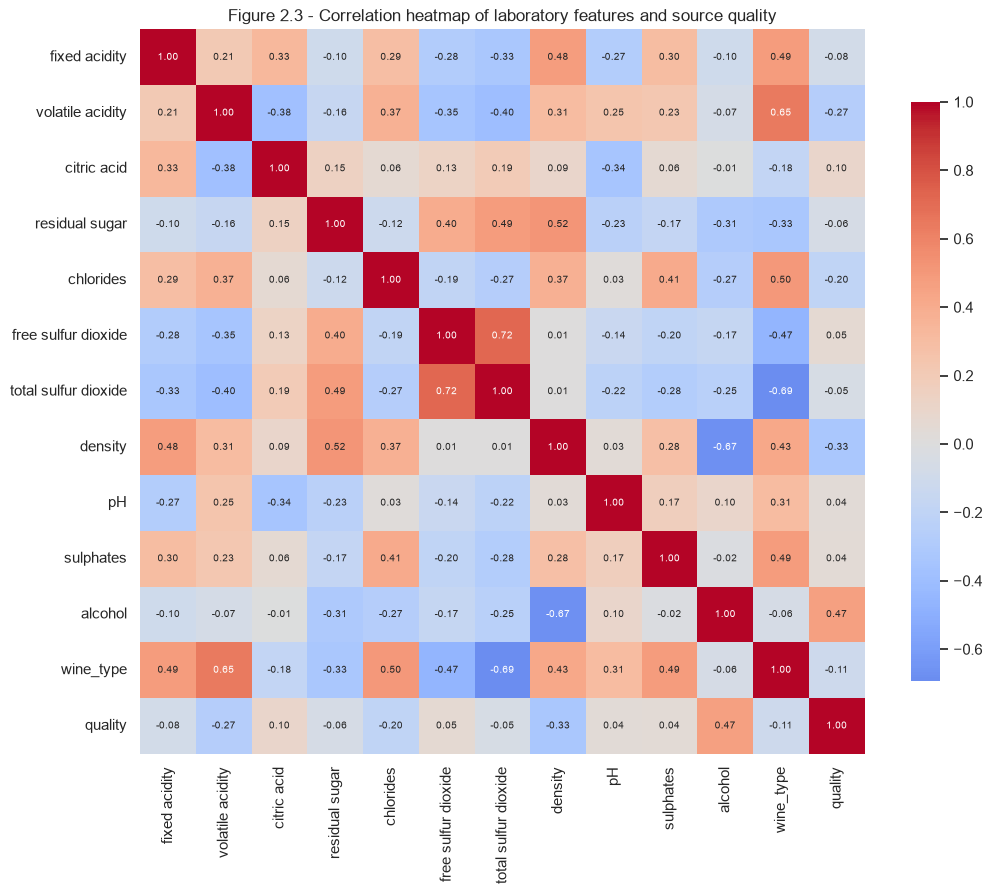

In [8]:
heatmap_columns = source_features + ["wine_type", "quality"]
source_corr = df[heatmap_columns].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(source_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
plt.title("Figure 2.3 - Correlation heatmap of laboratory features and source quality")
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_corr_heatmap.png", dpi=120)
plt.show()

# free and total sulfur dioxide correlate at 0.72 - chemically, total contains free 
# - so in Section 3 I test an engineered bound-SO2 feature to separate them.
# density vs alcohol, -0.67: more alcohol, less dense - alcohol is lighter than water

Table 2.3 - Feature correlations with the low-quality label
Positive values rise with low quality; alcohol has the strongest (negative) association.


,correlation_with_low_quality
alcohol,-0.4145
density,0.2872
volatile acidity,0.2699
chlorides,0.1874
wine_type,0.1177
citric acid,-0.0871
fixed acidity,0.0720
total sulfur dioxide,0.0494
residual sugar,0.0478
free sulfur dioxide,-0.0468


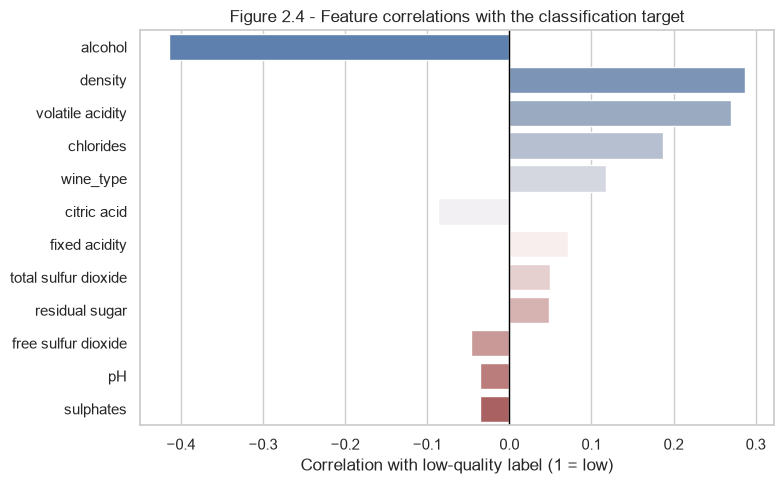

In [9]:
target_corr = (df[source_features + ["wine_type", "quality_label"]]
               .corr()["quality_label"].drop("quality_label"))
target_corr = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)
target_corr.rename("correlation_with_low_quality").to_csv(
    OUTPUT_DIR / "target_correlations_v8.csv", header=True)

print("Table 2.3 - Feature correlations with the low-quality label")
print("Positive values rise with low quality; alcohol has the strongest (negative) association.")
display(target_corr.rename("correlation_with_low_quality").round(4).to_frame())

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index,
            palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Correlation with low-quality label (1 = low)")
plt.ylabel("")
plt.title("Figure 2.4 - Feature correlations with the classification target")
plt.tight_layout()
plt.savefig(FIG_DIR / "v7_target_correlations.png", dpi=120)
plt.show()

# Alcohol has the strongest association with the target at -0.41
# Since low = 1, a negative correlation means that the highest the alcohol, the lower the probability of low quality

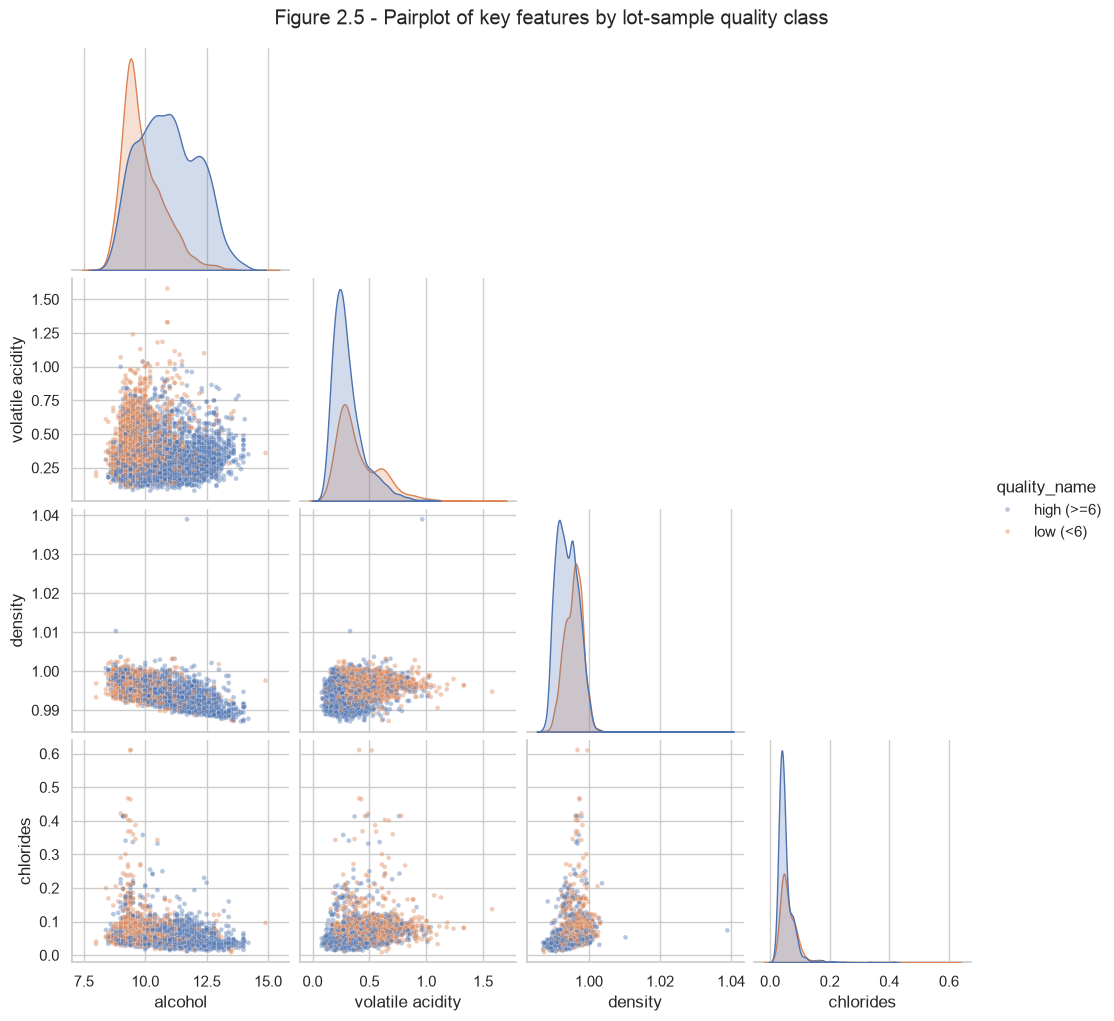

In [10]:
# Top-4 features by absolute correlation with the target (Table 2.3).
pair_cols = ["alcohol", "volatile acidity", "density", "chlorides"]

g = sns.pairplot(df, vars=pair_cols, hue="quality_name",
                 hue_order=["high (>=6)", "low (<6)"], corner=True,
                 plot_kws={"alpha": 0.4, "s": 12}, diag_kind="kde")
g.fig.suptitle("Figure 2.5 - Pairplot of key features by lot-sample quality class", y=1.02)
g.savefig(FIG_DIR / "v7_pairplot.png", dpi=110)
plt.show()

# the classes overlap heavily in every panel 
# no single feature separates low from high, 
# which is why a model that combines them is needed.

Interpretation - Data Understanding summary:

- **Data quality:** schema, numeric types, missing/non-finite values and physical consistency checks all pass. The IQR audit flags 1,473 rows (22.7%), but the values are plausible laboratory measurements, so they are retained.
- **Duplicates:** 1,177 exact duplicate rows are removed before splitting, so no identical record can appear in both training and test data.
- **Feature-to-feature:** free and total SO2 show the strongest positive correlation (0.72), expected because total chemically contains free; this motivates the bound-SO2 engineered feature tested in Section 3. Density and alcohol show the strongest negative correlation (-0.67), expected because alcohol is less dense than water. No other pair is strongly correlated, so the remaining features contribute largely separate information.
- **Relationship with the target:** with low as class 1, alcohol has the strongest association (-0.41): more alcohol, lower chance of low quality. Density (+0.29) and volatile acidity (+0.27) point toward low quality, though part of density's signal reflects its link with alcohol. Correlation is association, not causation.
- **Pairplot:** the four attributes shown are the top-4 by absolute target correlation. The classes overlap heavily in every panel - no single measurement separates low from high, so a model that combines features is required.

## 3. Data Preparation

Preparation uses four safeguards:
1. Exact duplicate rows are removed before target engineering and splitting, so no identical record can appear in both training and test data.
2. Source quality and the derived labels are excluded from the predictors, so the model cannot learn the target from a leaked feature. `wine_type` remains available as a predictor.
3. An 80/20 stratified split preserves the class ratio in both partitions and is checked for zero exact overlap.
4. Scaling and SMOTE live inside pipelines, so each cross-validation fold learns its preprocessing from its own training portion only (Chawla et al., 2002; Pedregosa et al., 2011).

Two engineered attributes are then tested on training data only: 
- bound SO2 (`total - free`), motivated by the 0.72 correlation seen in Section 2.5;
- and the free-SO2 ratio (`free / total`), a common quality indicator. 

They are retained only if cross-validated AUC or balanced accuracy improves by at least 0.01 without materially weakening sensitivity or specificity; the verdict is reported in Section 4.1.

In [11]:
LEAK_COLS = ["quality", "quality_label", "quality_name"]
feature_cols = [c for c in df.columns if c not in LEAK_COLS]
X = df[feature_cols]
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

train_keys = pd.MultiIndex.from_frame(X_train)
test_keys = pd.MultiIndex.from_frame(X_test)
overlap_count = int(test_keys.isin(train_keys).sum())
assert overlap_count == 0, "Exact feature rows leaked across train/test split"
assert set(LEAK_COLS).isdisjoint(X.columns), "Target-derived field entered predictors"

print("=" * 60)
print("Split summary")
print("=" * 60)
print("Train: %d rows | Test: %d rows (%.0f%%/%.0f%%)"
      % (len(X_train), len(X_test), 100 * len(X_train) / len(X),
         100 * len(X_test) / len(X)))
print("Exact train/test feature overlap:", overlap_count)

print("\n" + "-" * 60)
print("Class balance (share of each split)")
print("-" * 60)
balance = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).round(3),
    "test": y_test.value_counts(normalize=True).round(3),
}).rename(index=label_names)
print(balance.to_string())

print("\n" + "-" * 60)
print("Predictors (%d)" % len(feature_cols))
print("-" * 60)
print(", ".join(feature_cols))

Split summary
Train: 4256 rows | Test: 1064 rows (80%/20%)
Exact train/test feature overlap: 0

------------------------------------------------------------
Class balance (share of each split)
------------------------------------------------------------
               train   test
quality_label              
high (>=6)     0.626  0.626
low (<6)       0.374  0.374

------------------------------------------------------------
Predictors (12)
------------------------------------------------------------
fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol, wine_type


## 4. Modelling

### 4.1 Candidate models and rationale

The Decision Tree remains the required algorithm, but the post-submission discussion with
Dr Kamran identified a stronger experiment: compare several model families first on the
original training distribution, then with SMOTE, and finally with class weighting where the
algorithm supports it. Every comparison uses the same five stratified folds and ROC-AUC tuning.

| Model | What it tests | Required preprocessing |
|---|---|---|
| Logistic Regression | Interpretable linear probability boundary | StandardScaler |
| KNN | Local nonlinear relationships; sensitive to scale and 12 dimensions | StandardScaler |
| Decision Tree | Directly readable rules and feature interactions | None |
| SVM | Maximum-margin linear and nonlinear boundaries | StandardScaler |
| GaussianNB | Continuous measurements represented by class-conditional Gaussian distributions | None |
| BernoulliNB | Information loss when each measurement becomes above or below its training median | Fold-fitted median binarizer |
| MultinomialNB | Non-negative magnitude evidence under a count-like assumption | MinMaxScaler |
| ComplementNB | Naive Bayes variant designed to reduce imbalance effects in count-like data | MinMaxScaler |
| Random Forest | Ensemble averaging of many trees to reduce variance | None |

The majority classifier remains the no-skill baseline. Bernoulli, Multinomial and Complement
Naive Bayes are assumption stress tests: their fit to continuous laboratory measurements must
be judged from evidence, not presumed.

In [12]:
# 4.1 - Shared experiment definitions
import json
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import BernoulliNB, ComplementNB, GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler


class MedianBinarizer(BaseEstimator, TransformerMixin):
    'Learn feature medians from one training fold, then return binary evidence.'

    def fit(self, X_values, y_values=None):
        values = np.asarray(X_values)
        self.medians_ = np.median(values, axis=0)
        self.n_features_in_ = values.shape[1]
        return self

    def transform(self, X_values):
        return (np.asarray(X_values) > self.medians_).astype(float)


CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = {
    "roc_auc": "roc_auc",
    "sensitivity_low": make_scorer(recall_score, pos_label=1),
    "specificity_high": make_scorer(recall_score, pos_label=0),
    "balanced_accuracy": "balanced_accuracy",
    "f1_low": "f1",
}

MODEL_SPECS = {
    "Logistic Regression": {
        "preprocess": StandardScaler(),
        "model": LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE),
        "grid": {"model__C": [0.01, 0.1, 1, 10]},
    },
    "KNN": {
        "preprocess": StandardScaler(),
        "model": KNeighborsClassifier(),
        "grid": {
            "model__n_neighbors": [5, 11, 21, 31],
            "model__weights": ["uniform", "distance"],
        },
    },
    "Decision Tree": {
        "preprocess": "passthrough",
        "model": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "grid": {
            "model__max_depth": [3, 4, 5, 6, 8, None],
            "model__min_samples_leaf": [1, 5, 10, 20],
            "model__criterion": ["gini", "entropy"],
        },
    },
    "SVM": {
        "preprocess": StandardScaler(),
        "model": SVC(probability=True, random_state=RANDOM_STATE),
        "grid": {
            "model__kernel": ["rbf", "linear"],
            "model__C": [0.1, 1, 10],
        },
    },
    "GaussianNB": {
        "preprocess": "passthrough",
        "model": GaussianNB(),
        "grid": {"model__var_smoothing": [1e-9, 1e-7]},
    },
    "BernoulliNB": {
        "preprocess": MedianBinarizer(),
        "model": BernoulliNB(binarize=0.5),
        "grid": {"model__alpha": [0.1, 1.0]},
    },
    "MultinomialNB": {
        "preprocess": MinMaxScaler(),
        "model": MultinomialNB(),
        "grid": {"model__alpha": [0.1, 1.0]},
    },
    "ComplementNB": {
        "preprocess": MinMaxScaler(),
        "model": ComplementNB(),
        "grid": {"model__alpha": [0.1, 1.0]},
    },
    "Random Forest": {
        "preprocess": "passthrough",
        "model": RandomForestClassifier(
            n_estimators=200, random_state=RANDOM_STATE, n_jobs=1
        ),
        "grid": {
            "model__max_depth": [None, 10, 5],
            "model__min_samples_leaf": [1, 5, 20],
        },
    },
}

WEIGHTED_MODELS = {"Logistic Regression", "Decision Tree", "SVM", "Random Forest"}
matrix_rows = []
searches = {}
fitted_models = {}


def build_candidate(model_name, treatment):
    spec = MODEL_SPECS[model_name]
    estimator = clone(spec["model"])
    if treatment == "Class weight":
        estimator.set_params(class_weight="balanced")
    steps = [("preprocess", clone(spec["preprocess"]) if spec["preprocess"] != "passthrough" else "passthrough")]
    if treatment == "SMOTE":
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append(("model", estimator))
    return ImbPipeline(steps)


def run_search(model_name, treatment, X_values=X_train, y_values=y_train):
    candidate = build_candidate(model_name, treatment)
    search = GridSearchCV(
        candidate,
        MODEL_SPECS[model_name]["grid"],
        scoring=cv_scoring,
        refit="roc_auc",
        cv=CV,
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X_values, y_values)
    index = search.best_index_
    row = {
        "model": model_name,
        "treatment": treatment,
        "roc_auc": search.cv_results_["mean_test_roc_auc"][index],
        "roc_auc_std": search.cv_results_["std_test_roc_auc"][index],
        "sensitivity_low": search.cv_results_["mean_test_sensitivity_low"][index],
        "sensitivity_low_std": search.cv_results_["std_test_sensitivity_low"][index],
        "specificity_high": search.cv_results_["mean_test_specificity_high"][index],
        "specificity_high_std": search.cv_results_["std_test_specificity_high"][index],
        "balanced_accuracy": search.cv_results_["mean_test_balanced_accuracy"][index],
        "balanced_accuracy_std": search.cv_results_["std_test_balanced_accuracy"][index],
        "f1_low": search.cv_results_["mean_test_f1_low"][index],
        "f1_low_std": search.cv_results_["std_test_f1_low"][index],
        "best_params": json.dumps(search.best_params_, sort_keys=True),
    }
    matrix_rows.append(row)
    searches[(model_name, treatment)] = search
    fitted_models[(model_name, treatment)] = search.best_estimator_
    return row


print("Table 4.1 - Candidate families and experimental controls")
print("Nine model families will use the same folds, metrics and held-out boundary.")
display(pd.DataFrame({
    "Model": list(MODEL_SPECS),
    "Original": "Yes",
    "SMOTE": "Yes",
    "Class weight": ["Yes" if name in WEIGHTED_MODELS else "Not supported"
                     for name in MODEL_SPECS],
}).set_index("Model"))

Table 4.1 - Candidate families and experimental controls
Nine model families will use the same folds, metrics and held-out boundary.


,Original,SMOTE,Class weight
Model,,,
Logistic Regression,Yes,Yes,Yes
KNN,Yes,Yes,Not supported
Decision Tree,Yes,Yes,Yes
SVM,Yes,Yes,Yes
GaussianNB,Yes,Yes,Not supported
BernoulliNB,Yes,Yes,Not supported
MultinomialNB,Yes,Yes,Not supported
ComplementNB,Yes,Yes,Not supported
Random Forest,Yes,Yes,Yes


### 4.2 Experiment A - original distribution

This arm makes no attempt to balance the classes. Scaling, median binarisation and
non-negative scaling are model requirements, not balancing. Hyperparameters are selected by
five-fold ROC-AUC on the training partition only. The SVM search retains RBF and linear kernels;
poly and sigmoid were already weaker in v7 and are not repeated.

In [13]:
# 4.2 - Original training distribution
dummy_scores = cross_validate(
    DummyClassifier(strategy="most_frequent"), X_train, y_train,
    cv=CV, scoring=cv_scoring, n_jobs=1,
)
matrix_rows.append({
    "model": "Majority baseline",
    "treatment": "Original",
    **{metric: dummy_scores["test_" + metric].mean() for metric in cv_scoring},
    **{metric + "_std": dummy_scores["test_" + metric].std() for metric in cv_scoring},
    "best_params": "{}",
})

original_rows = [run_search(model_name, "Original") for model_name in MODEL_SPECS]
original_display = pd.DataFrame(original_rows).set_index("model")
print("Table 4.2 - Original-distribution tuning results (training CV)")
print("This is the untreated reference needed to measure every balancing trade-off.")
display(original_display[["roc_auc", "sensitivity_low", "specificity_high",
                          "balanced_accuracy", "f1_low"]].round(3))

Table 4.2 - Original-distribution tuning results (training CV)
This is the untreated reference needed to measure every balancing trade-off.


,roc_auc,sensitivity_low,specificity_high,balanced_accuracy,f1_low
model,,,,,
Logistic Regression,0.804,0.594,0.836,0.715,0.635
KNN,0.821,0.582,0.862,0.722,0.642
Decision Tree,0.792,0.647,0.794,0.721,0.650
SVM,0.827,0.636,0.845,0.740,0.671
GaussianNB,0.756,0.460,0.821,0.641,0.523
BernoulliNB,0.730,0.596,0.731,0.664,0.583
MultinomialNB,0.724,0.020,0.998,0.509,0.039
ComplementNB,0.724,0.451,0.754,0.603,0.483
Random Forest,0.836,0.624,0.853,0.738,0.667


### 4.3 Experiment B - SMOTE

SMOTE is inside the imbalanced-learn pipeline. For every validation rotation, preprocessing
and synthetic observations are learned from that fold's training portion only:

```text
CV training fold -> preprocessing -> SMOTE -> classifier
CV validation fold --------------------------> scoring
Held-out test set ----------------------------> final evaluation only
```

The held-out test set remains outside both GridSearchCV and SMOTE. It keeps the original class
distribution and is never resampled.

In [14]:
# 4.3 - SMOTE inside each training fold
smote_rows = [run_search(model_name, "SMOTE") for model_name in MODEL_SPECS]
smote_display = pd.DataFrame(smote_rows).set_index("model")
print("Table 4.3 - SMOTE tuning results (training CV)")
print("Synthetic minority observations exist only inside each training fold.")
display(smote_display[["roc_auc", "sensitivity_low", "specificity_high",
                       "balanced_accuracy", "f1_low"]].round(3))

Table 4.3 - SMOTE tuning results (training CV)
Synthetic minority observations exist only inside each training fold.


,roc_auc,sensitivity_low,specificity_high,balanced_accuracy,f1_low
model,,,,,
Logistic Regression,0.804,0.753,0.724,0.739,0.680
KNN,0.818,0.761,0.716,0.739,0.680
Decision Tree,0.790,0.758,0.701,0.730,0.671
SVM,0.828,0.777,0.731,0.754,0.697
GaussianNB,0.766,0.630,0.753,0.691,0.616
BernoulliNB,0.732,0.679,0.658,0.668,0.603
MultinomialNB,0.724,0.454,0.753,0.604,0.485
ComplementNB,0.724,0.454,0.753,0.604,0.485
Random Forest,0.833,0.730,0.772,0.751,0.691


### 4.4 Experiment C - class weighting

Logistic Regression, Decision Tree, SVM and Random Forest support
`class_weight="balanced"`. This arm changes the cost of minority-class errors without adding
or deleting observations. KNN and the Naive Bayes estimators do not expose the same parameter,
so manufacturing an equivalent would make the comparison less clear.

In [15]:
# 4.4 - Cost-sensitive training without synthetic observations
weighted_rows = [run_search(model_name, "Class weight")
                 for model_name in MODEL_SPECS if model_name in WEIGHTED_MODELS]
weighted_display = pd.DataFrame(weighted_rows).set_index("model")
print("Table 4.4 - Class-weight tuning results (training CV)")
print("Weights alter error cost while preserving every original training observation.")
display(weighted_display[["roc_auc", "sensitivity_low", "specificity_high",
                          "balanced_accuracy", "f1_low"]].round(3))

Table 4.4 - Class-weight tuning results (training CV)
Weights alter error cost while preserving every original training observation.


,roc_auc,sensitivity_low,specificity_high,balanced_accuracy,f1_low
model,,,,,
Logistic Regression,0.804,0.753,0.722,0.738,0.679
Decision Tree,0.791,0.748,0.704,0.726,0.666
SVM,0.830,0.782,0.731,0.756,0.700
Random Forest,0.835,0.748,0.766,0.757,0.699


### 4.5 Treatment comparison

The master table combines all model-treatment pairs. The delta table then subtracts each
model's untreated result, so a gain in sensitivity can be read beside any loss in specificity
or AUC. The plot draws the same change as an arrow from Original to SMOTE.

In [16]:
# 4.5.1 - Master CV matrix and treatment deltas
model_matrix = pd.DataFrame(matrix_rows)
model_matrix["passes_auc"] = model_matrix["roc_auc"] >= 0.75
model_matrix["passes_sensitivity"] = model_matrix["sensitivity_low"] >= 0.70
model_matrix["passes_specificity"] = model_matrix["specificity_high"] >= 0.70
model_matrix["passes_all_gates"] = model_matrix[
    ["passes_auc", "passes_sensitivity", "passes_specificity"]
].all(axis=1)
model_matrix.to_csv(OUTPUT_DIR / "model_matrix_cv_v8.csv", index=False)

delta_rows = []
for model_name in MODEL_SPECS:
    original = model_matrix[
        (model_matrix["model"] == model_name)
        & (model_matrix["treatment"] == "Original")
    ].iloc[0]
    for treatment in ("SMOTE", "Class weight"):
        treated = model_matrix[
            (model_matrix["model"] == model_name)
            & (model_matrix["treatment"] == treatment)
        ]
        if treated.empty:
            continue
        treated = treated.iloc[0]
        delta_rows.append({
            "model": model_name,
            "comparison": treatment + " - Original",
            "delta_sensitivity_low": treated["sensitivity_low"] - original["sensitivity_low"],
            "delta_specificity_high": treated["specificity_high"] - original["specificity_high"],
            "delta_balanced_accuracy": treated["balanced_accuracy"] - original["balanced_accuracy"],
            "delta_f1_low": treated["f1_low"] - original["f1_low"],
            "delta_roc_auc": treated["roc_auc"] - original["roc_auc"],
        })
treatment_deltas = pd.DataFrame(delta_rows)
treatment_deltas.to_csv(OUTPUT_DIR / "treatment_deltas_v8.csv", index=False)

print("Table 4.5 - Master model-treatment matrix (training CV)")
print("The gates are applied before any held-out test result is opened.")
display(model_matrix[["model", "treatment", "roc_auc", "sensitivity_low",
                      "specificity_high", "balanced_accuracy", "f1_low",
                      "passes_all_gates"]].round(3))

print("\nTable 4.6 - Treatment deltas against each untreated model")
print("Positive sensitivity with negative specificity quantifies the review-workload trade-off.")
display(treatment_deltas.round(3))

Table 4.5 - Master model-treatment matrix (training CV)
The gates are applied before any held-out test result is opened.


,model,treatment,roc_auc,sensitivity_low,specificity_high,balanced_accuracy,f1_low,passes_all_gates
0,Majority baseline,Original,0.500,0.000,1.000,0.500,0.000,False
1,Logistic Regression,Original,0.804,0.594,0.836,0.715,0.635,False
2,KNN,Original,0.821,0.582,0.862,0.722,0.642,False
3,Decision Tree,Original,0.792,0.647,0.794,0.721,0.650,False
4,SVM,Original,0.827,0.636,0.845,0.740,0.671,False
5,GaussianNB,Original,0.756,0.460,0.821,0.641,0.523,False
6,BernoulliNB,Original,0.730,0.596,0.731,0.664,0.583,False
7,MultinomialNB,Original,0.724,0.020,0.998,0.509,0.039,False
8,ComplementNB,Original,0.724,0.451,0.754,0.603,0.483,False
9,Random Forest,Original,0.836,0.624,0.853,0.738,0.667,False



Table 4.6 - Treatment deltas against each untreated model
Positive sensitivity with negative specificity quantifies the review-workload trade-off.


,model,comparison,delta_sensitivity_low,delta_specificity_high,delta_balanced_accuracy,delta_f1_low,delta_roc_auc
0,Logistic Regression,SMOTE - Original,0.159,-0.111,0.024,0.045,-0.000
1,Logistic Regression,Class weight - Original,0.160,-0.113,0.023,0.044,-0.000
2,KNN,SMOTE - Original,0.179,-0.146,0.016,0.038,-0.003
3,Decision Tree,SMOTE - Original,0.111,-0.093,0.009,0.022,-0.002
4,Decision Tree,Class weight - Original,0.101,-0.090,0.005,0.017,-0.000
5,SVM,SMOTE - Original,0.141,-0.114,0.013,0.027,0.000
6,SVM,Class weight - Original,0.146,-0.114,0.016,0.029,0.002
7,GaussianNB,SMOTE - Original,0.170,-0.069,0.051,0.094,0.010
8,BernoulliNB,SMOTE - Original,0.082,-0.073,0.005,0.020,0.001
9,MultinomialNB,SMOTE - Original,0.434,-0.245,0.095,0.446,-0.000


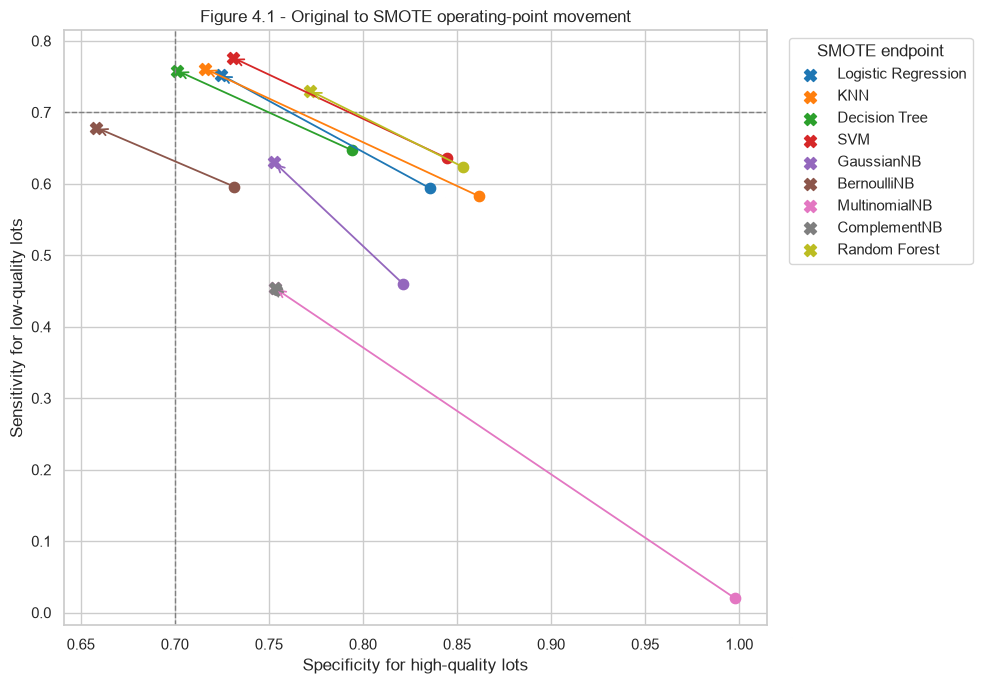

Figure 4.1 - Circles are Original; X markers are SMOTE; arrows show the change.


In [17]:
# 4.5.2 - Sensitivity-specificity movement caused by SMOTE
fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("tab10", n_colors=len(MODEL_SPECS))
for colour, model_name in zip(palette, MODEL_SPECS):
    original = model_matrix[(model_matrix["model"] == model_name)
                            & (model_matrix["treatment"] == "Original")].iloc[0]
    smote = model_matrix[(model_matrix["model"] == model_name)
                         & (model_matrix["treatment"] == "SMOTE")].iloc[0]
    ax.scatter(original["specificity_high"], original["sensitivity_low"],
               color=colour, marker="o", s=55)
    ax.scatter(smote["specificity_high"], smote["sensitivity_low"],
               color=colour, marker="X", s=75, label=model_name)
    ax.annotate("", xy=(smote["specificity_high"], smote["sensitivity_low"]),
                xytext=(original["specificity_high"], original["sensitivity_low"]),
                arrowprops={"arrowstyle": "->", "color": colour, "lw": 1.3})
ax.axhline(0.70, color="grey", linestyle="--", linewidth=1)
ax.axvline(0.70, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Specificity for high-quality lots")
ax.set_ylabel("Sensitivity for low-quality lots")
ax.set_title("Figure 4.1 - Original to SMOTE operating-point movement")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="SMOTE endpoint")
plt.tight_layout()
plt.savefig(FIG_DIR / "v8_sampling_tradeoffs.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure 4.1 - Circles are Original; X markers are SMOTE; arrows show the change.")

### 4.6 Gates and finalist selection

The original v7 gates remain unchanged: AUC at least 0.75, sensitivity at least 0.70 and
specificity at least 0.70. Among candidates passing all gates, balanced accuracy ranks them.
Scores within 0.01 are treated as a technical tie and resolved by interpretability: one tree's
rules first, then linear coefficients or simple class distributions, then ensemble or local
similarity models.

Four roles are frozen from training CV: best untreated, best SMOTE, best class-weighted and best
ensemble. Duplicate winners appear only once in the held-out evaluation.

In [18]:
# 4.6 - Apply gates and freeze finalists without reading X_test
INTERPRETABILITY_RANK = {
    "Decision Tree": 1,
    "Logistic Regression": 2,
    "GaussianNB": 3,
    "BernoulliNB": 4,
    "MultinomialNB": 5,
    "ComplementNB": 6,
    "Random Forest": 7,
    "SVM": 8,
    "KNN": 9,
}


def best_in_pool(pool):
    passing = pool[pool["passes_all_gates"]]
    candidates = passing if not passing.empty else pool
    return candidates.sort_values(
        ["balanced_accuracy", "roc_auc"], ascending=False
    ).iloc[0]


role_pools = {
    "best untreated": model_matrix[
        (model_matrix["treatment"] == "Original")
        & (model_matrix["model"] != "Majority baseline")
    ],
    "best SMOTE": model_matrix[model_matrix["treatment"] == "SMOTE"],
    "best class weighted": model_matrix[model_matrix["treatment"] == "Class weight"],
    "best ensemble": model_matrix[model_matrix["model"] == "Random Forest"],
}
role_winners = []
for role, pool in role_pools.items():
    winner = best_in_pool(pool)
    role_winners.append({"role": role, "model": winner["model"],
                         "treatment": winner["treatment"]})

passing = model_matrix[model_matrix["passes_all_gates"]].copy()
if passing.empty:
    approved = model_matrix.sort_values("balanced_accuracy", ascending=False).iloc[0]
else:
    best_balanced_accuracy = passing["balanced_accuracy"].max()
    tied = passing[
        passing["balanced_accuracy"] >= best_balanced_accuracy - 0.01
    ].copy()
    tied["interpretability_rank"] = tied["model"].map(INTERPRETABILITY_RANK)
    approved = tied.sort_values(
        ["interpretability_rank", "balanced_accuracy"], ascending=[True, False]
    ).iloc[0]

role_winners.append({"role": "approved", "model": approved["model"],
                     "treatment": approved["treatment"]})
selection_summary = pd.DataFrame(role_winners)
selection_summary.to_csv(OUTPUT_DIR / "selection_summary_v8.csv", index=False)

finalist_keys = []
for row in role_winners:
    key = (row["model"], row["treatment"])
    if key not in finalist_keys:
        finalist_keys.append(key)
approved_key = (approved["model"], approved["treatment"])

print("Table 4.7 - Frozen finalist roles from training CV")
print("The held-out test remains unopened while these roles and the recommendation are fixed.")
display(selection_summary)
print("\nApproved from CV:", approved_key)

Table 4.7 - Frozen finalist roles from training CV
The held-out test remains unopened while these roles and the recommendation are fixed.


,role,model,treatment
0,best untreated,SVM,Original
1,best SMOTE,SVM,SMOTE
2,best class weighted,Random Forest,Class weight
3,best ensemble,Random Forest,Class weight
4,approved,Random Forest,Class weight



Approved from CV: ('Random Forest', 'Class weight')


### 4.7 Feature ablation

The v7 sulfur experiment remains, now applied to the CV-approved model. Bound SO2 and the free
SO2 ratio are added together, the complete model pipeline is re-tuned, and the pair is retained
only if AUC or balanced accuracy improves by at least 0.01 without reducing sensitivity or
specificity by more than 0.02.

In [19]:
# 4.7 - Training-only feature ablation on the CV-approved model
def add_sulfur_features(frame):
    result = frame.copy()
    result["bound_sulfur_dioxide"] = (
        result["total sulfur dioxide"] - result["free sulfur dioxide"]
    )
    result["free_so2_ratio"] = (
        result["free sulfur dioxide"] / result["total sulfur dioxide"]
    )
    return result


X_train_engineered = add_sulfur_features(X_train)
engineered_search = GridSearchCV(
    build_candidate(*approved_key),
    MODEL_SPECS[approved_key[0]]["grid"],
    scoring=cv_scoring,
    refit="roc_auc",
    cv=CV,
    n_jobs=1,
    error_score="raise",
)
engineered_search.fit(X_train_engineered, y_train)
engineered_index = engineered_search.best_index_
engineered_metrics = {
    metric: engineered_search.cv_results_["mean_test_" + metric][engineered_index]
    for metric in cv_scoring
}
base_metrics = model_matrix[
    (model_matrix["model"] == approved_key[0])
    & (model_matrix["treatment"] == approved_key[1])
].iloc[0]
auc_gain = engineered_metrics["roc_auc"] - base_metrics["roc_auc"]
balanced_gain = engineered_metrics["balanced_accuracy"] - base_metrics["balanced_accuracy"]
material_gain = max(auc_gain, balanced_gain)
retained = bool(
    material_gain >= 0.01
    and engineered_metrics["sensitivity_low"] >= base_metrics["sensitivity_low"] - 0.02
    and engineered_metrics["specificity_high"] >= base_metrics["specificity_high"] - 0.02
)

feature_ablation = pd.DataFrame([
    {
        "feature_set": "Base 12 features",
        "roc_auc": base_metrics["roc_auc"],
        "sensitivity_low": base_metrics["sensitivity_low"],
        "specificity_high": base_metrics["specificity_high"],
        "balanced_accuracy": base_metrics["balanced_accuracy"],
        "material_gain": 0.0,
        "retained": not retained,
    },
    {
        "feature_set": "Base + bound SO2 + free SO2 ratio",
        **engineered_metrics,
        "material_gain": material_gain,
        "retained": retained,
    },
])
feature_ablation.to_csv(OUTPUT_DIR / "feature_ablation_v8.csv", index=False)
approved_uses_engineered = retained
if retained:
    fitted_models[approved_key] = engineered_search.best_estimator_

print("Table 4.8 - Feature ablation on the CV-approved pipeline")
print("The 0.01 materiality rule decides whether two extra sulfur features earn their cost.")
display(feature_ablation.round(4))

Table 4.8 - Feature ablation on the CV-approved pipeline
The 0.01 materiality rule decides whether two extra sulfur features earn their cost.


,feature_set,roc_auc,sensitivity_low,specificity_high,balanced_accuracy,material_gain,retained,f1_low
0,Base 12 features,0.8349,0.7484,0.7659,0.7572,0.0000,True,NaN
1,Base + bound SO2 + free SO2 ratio,0.8362,0.7503,0.7644,0.7574,0.0013,False,0.6995


**Interpretation:**

- Across the nine model families, SMOTE changed mean sensitivity by +0.154,
  mean specificity by -0.104, and mean AUC by +0.000. This separates
  an operating-point change from a ranking improvement.
- The best Random Forest treatment reached balanced accuracy 0.757,
  compared with 0.730 for the best single Decision Tree.
  The ensemble comparison therefore measures the benefit of averaging many trees against
  the loss of one directly readable rule set.
- Gaussian Naive Bayes keeps continuous measurements, while Bernoulli, Multinomial and
  Complement variants transform them to fit different assumptions. Their result is evidence
  about assumption fit, not a success or failure label.
- The sulfur feature set was rejected.
  Its best material gain was 0.0013 against the predeclared
  0.01 rule.
- The frozen recommendation from training CV is **Random Forest with
  class weighting**, with AUC 0.835, sensitivity
  0.748, specificity 0.766,
  and balanced accuracy 0.757.

## 5. Evaluation

The test partition is opened only after the model matrix, gates, finalist roles and feature
ablation are frozen. It is used with its original distribution and is never resampled. The
finalist table answers whether each training-CV result generalises to unseen observations.

In [20]:
# 5.0 - Evaluate only the frozen unique finalists on the untouched test set
def model_scores(model, X_values):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_values)[:, 1]
    return model.decision_function(X_values)


def class_metrics(model, X_values, y_values):
    prediction = model.predict(X_values)
    score = model_scores(model, X_values)
    tn, fp, fn, tp = confusion_matrix(y_values, prediction, labels=[0, 1]).ravel()
    sensitivity = recall_score(y_values, prediction, pos_label=1)
    specificity = recall_score(y_values, prediction, pos_label=0)
    return {
        "accuracy": accuracy_score(y_values, prediction),
        "precision_low": precision_score(y_values, prediction, pos_label=1, zero_division=0),
        "sensitivity_low": sensitivity,
        "specificity_high": specificity,
        "f1_low": f1_score(y_values, prediction, pos_label=1, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_values, prediction),
        "g_mean": np.sqrt(sensitivity * specificity),
        "roc_auc": roc_auc_score(y_values, score),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


test_rows = []
for model_name, treatment in finalist_keys:
    X_final_test = (
        add_sulfur_features(X_test)
        if (model_name, treatment) == approved_key and approved_uses_engineered
        else X_test
    )
    test_rows.append({
        "model": model_name,
        "treatment": treatment,
        **class_metrics(fitted_models[(model_name, treatment)], X_final_test, y_test),
    })
finalist_test = pd.DataFrame(test_rows)
finalist_test.to_csv(OUTPUT_DIR / "finalist_test_metrics_v8.csv", index=False)

print("Table 5.1 - Frozen finalists on the untouched held-out test")
print("These are the only candidates evaluated after the CV decision was frozen.")
display(finalist_test[["model", "treatment", "accuracy", "precision_low",
                       "sensitivity_low", "specificity_high", "f1_low",
                       "balanced_accuracy", "g_mean", "roc_auc"]].round(3))

Table 5.1 - Frozen finalists on the untouched held-out test
These are the only candidates evaluated after the CV decision was frozen.


,model,treatment,accuracy,precision_low,sensitivity_low,specificity_high,f1_low,balanced_accuracy,g_mean,roc_auc
0,SVM,Original,0.762,0.723,0.590,0.865,0.650,0.728,0.715,0.824
1,SVM,SMOTE,0.762,0.664,0.739,0.776,0.699,0.757,0.757,0.825
2,Random Forest,Class weight,0.772,0.688,0.714,0.806,0.700,0.760,0.759,0.834


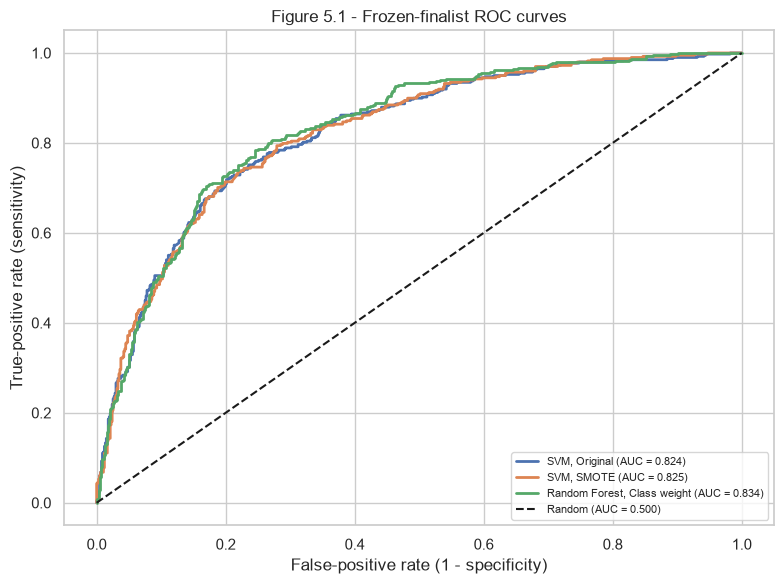

Figure 5.1 - ROC compares ranking; the confusion matrices show the operating point.


In [21]:
# 5.0.1 - ROC curves for frozen finalists
plt.figure(figsize=(8, 6))
for model_name, treatment in finalist_keys:
    X_final_test = (
        add_sulfur_features(X_test)
        if (model_name, treatment) == approved_key and approved_uses_engineered
        else X_test
    )
    score = model_scores(fitted_models[(model_name, treatment)], X_final_test)
    fpr, tpr, _ = roc_curve(y_test, score, pos_label=1)
    auc = roc_auc_score(y_test, score)
    plt.plot(fpr, tpr, linewidth=2,
             label=f"{model_name}, {treatment} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
plt.xlabel("False-positive rate (1 - specificity)")
plt.ylabel("True-positive rate (sensitivity)")
plt.title("Figure 5.1 - Frozen-finalist ROC curves")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "v8_finalist_roc.png", dpi=120)
plt.show()
print("Figure 5.1 - ROC compares ranking; the confusion matrices show the operating point.")

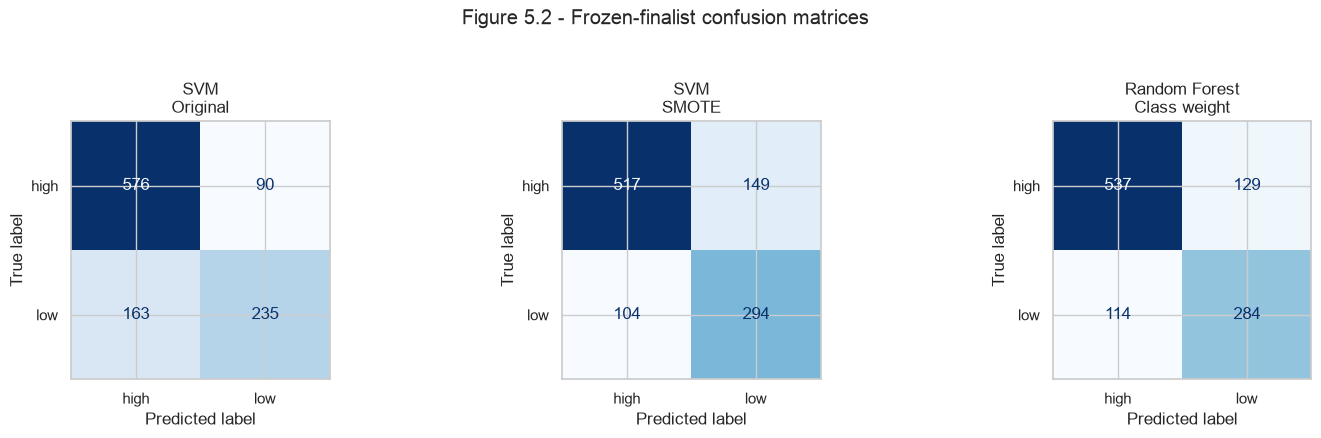

Figure 5.2 - FN is a weak lot missed; FP is an acceptable lot sent to review.


In [22]:
# 5.0.2 - Confusion matrices for frozen finalists
n_finalists = len(finalist_keys)
fig, axes = plt.subplots(1, n_finalists, figsize=(5 * n_finalists, 4.2))
axes = np.atleast_1d(axes)
for ax, (model_name, treatment) in zip(axes, finalist_keys):
    X_final_test = (
        add_sulfur_features(X_test)
        if (model_name, treatment) == approved_key and approved_uses_engineered
        else X_test
    )
    prediction = fitted_models[(model_name, treatment)].predict(X_final_test)
    cm = confusion_matrix(y_test, prediction, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["high", "low"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"{model_name}\n{treatment}")
fig.suptitle("Figure 5.2 - Frozen-finalist confusion matrices", y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "v8_finalist_confusion_matrices.png", dpi=120,
            bbox_inches="tight")
plt.show()
print("Figure 5.2 - FN is a weak lot missed; FP is an acceptable lot sent to review.")

In [23]:
# 5.0.3 - Classification report for the approved model
approved_model = fitted_models[approved_key]
X_approved_train = add_sulfur_features(X_train) if approved_uses_engineered else X_train
X_approved_test = add_sulfur_features(X_test) if approved_uses_engineered else X_test
approved_prediction = approved_model.predict(X_approved_test)
approved_report = pd.DataFrame(classification_report(
    y_test,
    approved_prediction,
    target_names=["high (>=6)", "low (<6)"],
    output_dict=True,
    zero_division=0,
)).T.round(3)
approved_report.to_csv(OUTPUT_DIR / "classification_report_v8.csv")
print("Table 5.2 - Classification report for the CV-approved model")
print("The low-class row is the operational screening result; accuracy alone is insufficient.")
display(approved_report)

Table 5.2 - Classification report for the CV-approved model
The low-class row is the operational screening result; accuracy alone is insufficient.


,precision,recall,f1-score,support
high (>=6),0.825,0.806,0.815,666.000
low (<6),0.688,0.714,0.700,398.000
accuracy,0.772,0.772,0.772,0.772
macro avg,0.756,0.760,0.758,1064.000
weighted avg,0.774,0.772,0.772,1064.000


### 5.1 Explainable AI

The explanation method follows the approved model instead of forcing every model into a tree
explanation. Tree-based winners use `TreeExplainer`; Logistic Regression uses coefficients and
`LinearExplainer`. A model-agnostic SHAP fallback remains available if another family wins.
Every explanation targets class 1, which is low quality.

In [24]:
# 5.1.1 - Prepare class-1 explanations for the approved pipeline
def transform_for_estimator(pipeline, frame):
    transformed = frame
    for _, step in pipeline.steps[:-1]:
        if hasattr(step, "transform"):
            transformed = step.transform(transformed)
    return np.asarray(transformed)


approved_model_name, approved_treatment = approved_key
approved_estimator = approved_model.named_steps["model"]
approved_feature_names = list(X_approved_test.columns)
X_train_model = transform_for_estimator(approved_model, X_approved_train)
X_test_model = transform_for_estimator(approved_model, X_approved_test)

if approved_model_name in {"Decision Tree", "Random Forest"}:
    explanation_kind = "tree probability"
    explanation_limit = min(len(X_test_model), 500 if approved_model_name == "Random Forest" else len(X_test_model))
    explained_positions = np.arange(explanation_limit)
    explainer = shap.TreeExplainer(approved_estimator)
    shap_all = explainer(X_test_model[explained_positions])
    if shap_all.values.ndim == 3:
        low_index = list(approved_estimator.classes_).index(1)
        low_values = shap_all.values[:, :, low_index]
        base_values = np.asarray(shap_all.base_values)
        low_base = base_values[:, low_index] if base_values.ndim == 2 else np.repeat(
            base_values[low_index], explanation_limit
        )
    else:
        low_values = shap_all.values
        low_base = shap_all.base_values
    low_shap = shap.Explanation(
        values=low_values,
        base_values=low_base,
        data=X_test_model[explained_positions],
        feature_names=approved_feature_names,
    )
    target_score = approved_estimator.predict_proba(
        X_test_model[explained_positions]
    )[:, list(approved_estimator.classes_).index(1)]
elif approved_model_name == "Logistic Regression":
    explanation_kind = "linear log-odds"
    explained_positions = np.arange(len(X_test_model))
    background = shap.sample(X_train_model, min(300, len(X_train_model)), random_state=RANDOM_STATE)
    explainer = shap.LinearExplainer(approved_estimator, background)
    low_shap = explainer(X_test_model)
    target_score = approved_estimator.decision_function(X_test_model)
else:
    explanation_kind = "model-agnostic probability"
    explained_positions = np.arange(min(200, len(X_test_model)))
    background = shap.sample(X_train_model, min(100, len(X_train_model)), random_state=RANDOM_STATE)
    explainer = shap.Explainer(
        lambda values: approved_estimator.predict_proba(values)[:, 1],
        background,
        feature_names=approved_feature_names,
    )
    low_shap = explainer(X_test_model[explained_positions])
    target_score = approved_estimator.predict_proba(
        X_test_model[explained_positions]
    )[:, 1]

reconstructed_score = np.asarray(low_shap.base_values) + np.asarray(low_shap.values).sum(axis=1)
max_additivity_error = float(np.max(np.abs(reconstructed_score - target_score)))
print("Explanation method:", explanation_kind)
print("Explained held-out rows:", len(explained_positions))
print("Maximum additivity error: %.2e" % max_additivity_error)

Explanation method: tree probability
Explained held-out rows: 500
Maximum additivity error: 3.00e-15


**Interpretation:**

- The explanation method is selected from the approved model family.
- The additivity check verifies that the feature contributions reconstruct the explained
  class-1 score at machine precision for tree and linear explainers.
- For Random Forest, a fixed held-out sample limits explanation cost without entering training.

Table 5.3 - Global SHAP importance for the approved model
Mean absolute SHAP ranks which laboratory measurements move low-quality risk most.


,feature,mean_absolute_shap
0,alcohol,0.1234
1,volatile acidity,0.0643
2,density,0.0476
3,free sulfur dioxide,0.0348
4,chlorides,0.0322
5,sulphates,0.0276
6,citric acid,0.0247
7,total sulfur dioxide,0.0196
8,residual sugar,0.0176
9,pH,0.0163


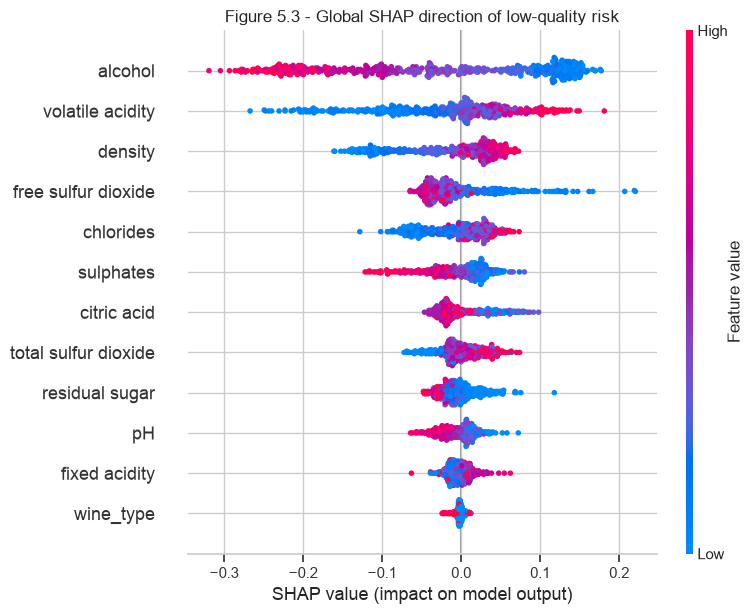

In [25]:
# 5.1.2 - Global class-1 SHAP importance and direction
shap_global = pd.DataFrame({
    "feature": approved_feature_names,
    "mean_absolute_shap": np.abs(low_shap.values).mean(axis=0),
}).sort_values("mean_absolute_shap", ascending=False).reset_index(drop=True)
shap_global.to_csv(OUTPUT_DIR / "shap_global_importance_v8.csv", index=False)

print("Table 5.3 - Global SHAP importance for the approved model")
print("Mean absolute SHAP ranks which laboratory measurements move low-quality risk most.")
display(shap_global.round(4))

shap.plots.beeswarm(low_shap, max_display=min(14, len(approved_feature_names)), show=False)
plt.title("Figure 5.3 - Global SHAP direction of low-quality risk")
plt.tight_layout()
plt.savefig(FIG_DIR / "v8_shap_global.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation:**

- Mean absolute SHAP ranks overall influence; the beeswarm adds direction and distribution.
- Positive values push the score toward class 1, meaning higher low-quality risk.
- These are model associations, not evidence that changing one chemical measurement will cause
  a sensory-quality change.

Representative correctly flagged low-quality lot: row 1855
Predicted low-quality probability: 0.719
Table 5.4 - Local SHAP decomposition
The largest positive and negative contributions explain why this lot was reviewed.


,feature,value,shap_toward_low_quality
0,alcohol,9.4000,0.1479
1,volatile acidity,0.4100,0.0946
2,density,0.9968,0.0584
3,citric acid,0.3300,-0.0306
4,residual sugar,10.1000,-0.0235
5,chlorides,0.0430,-0.0229


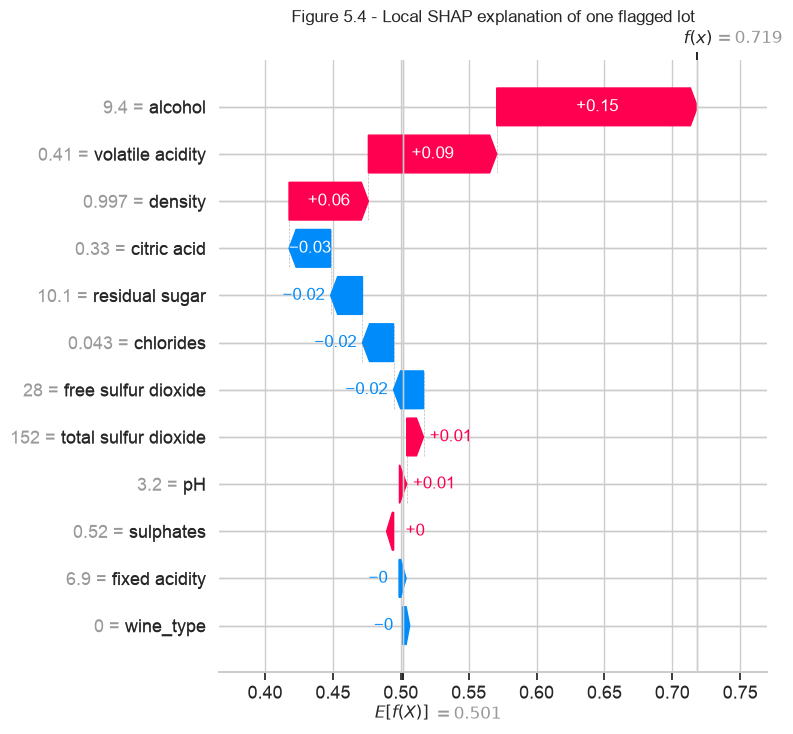

In [26]:
# 5.1.3 - Local explanation of one correctly flagged low-quality lot
explained_y = y_test.iloc[explained_positions].to_numpy()
explained_prediction = approved_model.predict(X_approved_test.iloc[explained_positions])
true_positive_positions = np.flatnonzero(
    (explained_y == 1) & (explained_prediction == 1)
)
if len(true_positive_positions):
    explained_probabilities = approved_model.predict_proba(
        X_approved_test.iloc[explained_positions]
    )[:, list(approved_model.classes_).index(1)]
    tp_probabilities = explained_probabilities[true_positive_positions]
    local_position = int(true_positive_positions[
        np.argmin(np.abs(tp_probabilities - np.median(tp_probabilities)))
    ])
else:
    local_position = int(np.argmax(target_score))

local_explanation = low_shap[local_position]
local_table = pd.DataFrame({
    "feature": approved_feature_names,
    "value": X_test_model[explained_positions[local_position]],
    "shap_toward_low_quality": local_explanation.values,
}).assign(
    absolute_shap=lambda frame: frame["shap_toward_low_quality"].abs()
).sort_values("absolute_shap", ascending=False).drop(
    columns="absolute_shap"
).reset_index(drop=True)
local_table.to_csv(OUTPUT_DIR / "shap_local_example_v8.csv", index=False)

source_position = explained_positions[local_position]
source_index = X_test.index[source_position]
local_probability = approved_model.predict_proba(
    X_approved_test.iloc[[source_position]]
)[0, list(approved_model.classes_).index(1)]
print("Representative correctly flagged low-quality lot: row", source_index)
print("Predicted low-quality probability: %.3f" % local_probability)
print("Table 5.4 - Local SHAP decomposition")
print("The largest positive and negative contributions explain why this lot was reviewed.")
display(local_table.head(6).round(4))

shap.plots.waterfall(local_explanation, max_display=min(14, len(approved_feature_names)), show=False)
plt.title("Figure 5.4 - Local SHAP explanation of one flagged lot")
plt.tight_layout()
plt.savefig(FIG_DIR / "v8_shap_local.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation:**

- This local explanation answers why one specific lot crossed the review threshold.
- Quality-control staff can verify the dominant measurements against the laboratory record.
- Human review remains necessary because a plausible model explanation is not a causal finding.

### 5.2 Operational result

The frozen **Random Forest with class weighting** is the approved model. On the
held-out test it achieved AUC 0.834, sensitivity
0.714, specificity 0.806,
balanced accuracy 0.760, and low-class F1
0.700.

Operationally, it caught 284 of
398 genuinely low-quality lots, missed
114, and sent 129 acceptable lots for
unnecessary review. The test set retained its original class distribution and was never
resampled.

### 5.3 Approval decision

| Finalist | Treatment | Decision | Reason |
|---|---|---|---|
| SVM | Original | **Do not approve** | Misses test sensitivity gate |
| SVM | SMOTE | **Do not approve** | Passes test gates, but was not the CV-selected recommendation |
| Random Forest | Class weight | **Approve for controlled pilot** | Selected by CV gates, balanced accuracy and interpretability rule |

Approval means human-supervised triage, not automated release or rejection. Threshold calibration remains deferred until real business costs are available.

## 6. Deployment / Lessons Learned

### What went well
- The expanded matrix turned model selection into a controlled comparison: nine families,
  identical folds, three treatment strategies and one set of business gates.
- Running the original distribution first made the effect of SMOTE and class weighting
  measurable rather than assumed.
- The final Random Forest recommendation follows the evidence instead of preserving
  the v7 choice by default.

### Challenges
- Classification requires several metrics at once. Higher sensitivity can create more false
  alarms, while higher AUC does not guarantee a useful default threshold.
- Sampling, class weighting and ensemble learning solve different problems. SMOTE changes
  the training distribution, weighting changes error cost, and Random Forest reduces the
  variance of one tree by averaging many trees.
- Naive Bayes variants required different preprocessing because wine chemistry is continuous,
  while Bernoulli expects binary evidence and Multinomial or Complement models expect
  non-negative magnitude features.

### What can be improved in the future
- Estimate the real cost of a missed weak lot, an unnecessary hold and another tasting, then
  calibrate the decision threshold instead of accepting 0.5 automatically.
- Collect real lot IDs, timestamps, process conditions and release outcomes, then validate on
  a later production period or an independent producer.
- Monitor probability calibration, data drift, hold rate, weak-lot escapes and red versus white
  performance during a human-supervised shadow pilot.

## Academic Integrity Declaration

I declare that except where I have referenced, the work I am submitting for this assessment task is my own work. I have read and am aware of the Torrens University Australia Academic Integrity Policy and Procedure viewable online at http://www.torrens.edu.au/policies-and-forms

I am aware that I need to keep a copy of all submitted material and their drafts, and I will do so accordingly.

## Statement of Acknowledgement

I acknowledge that I have used the following AI tool(s) in the creation of this report:
- Anthropic Claude Opus 4.8
- OpenAI ChatGPT Codex 5.5

Both tools were used to assist with understanding ML concepts, structuring the technical pipeline,
improving clarity of academic language, and supporting APA 7th referencing conventions.

Prompt examples:
1. "Explain why low-quality wine should be the positive class and how sensitivity, specificity, balanced accuracy and G-mean relate to its confusion matrix."
2. "Design a leakage-safe comparison between class weighting and SMOTE where synthetic samples are created only inside cross-validation training folds."
3. "Explain SVM margin, support vectors, C, gamma and the kernel trick, then propose a GridSearchCV comparison scored by ROC-AUC."

I confirm that the use of these tools has been in accordance with the Torrens University Australia
Academic Integrity Policy and TUA, Think and MDS's Position Paper on the Use of AI. I confirm that
the final output is authored by me and represents my own critical thinking, analysis, and synthesis
of sources. I take full responsibility for the final content of this report.

## References

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., & Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc. https://www.the-modeling-agency.com/crisp-dm.pdf

Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: Synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research, 16*, 321-357. https://doi.org/10.1613/jair.953

Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning, 20*, 273-297. https://doi.org/10.1007/BF00994018

Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems, 47*(4), 547-553. https://doi.org/10.1016/j.dss.2009.05.016

Lundberg, S. M., & Lee, S.-I. (2017). A unified approach to interpreting model predictions. *Advances in Neural Information Processing Systems, 30*, 4765-4774. https://proceedings.neurips.cc/paper/2017/hash/8a20a8621978632d76c43dfd28b67767-Abstract.html

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

University of California, Irvine. (n.d.). *Wine Quality* [Data set]. UCI Machine Learning Repository. Retrieved July 2, 2026, from https://archive.ics.uci.edu/dataset/186/wine+quality

## Appendix A - Glossary

| Term | Meaning in this assessment |
|---|---|
| Cross-validation (CV) | Five repeated train-validation rotations inside the training partition |
| Held-out test set | Untouched 20% used only after finalist selection; never resampled |
| ROC-AUC | Ability to rank low-quality samples above high-quality samples across thresholds |
| Sensitivity | Share of genuinely low-quality lots correctly flagged |
| Specificity | Share of genuinely high-quality lots correctly cleared |
| Precision | Share of low-quality flags that are correct |
| Balanced accuracy | Mean of sensitivity and specificity |
| Class imbalance | Unequal frequency: 37.4% low versus 62.6% high after deduplication |
| Original treatment | Training on the observed class distribution without balancing |
| SMOTE | Synthetic minority observations created only inside CV training folds |
| Class weighting | Higher error cost for the minority class without synthetic observations |
| Ensemble learning | Combining multiple learners; Random Forest averages many trees |
| Logistic Regression | Linear classifier producing class probabilities from weighted features |
| KNN | Classifier based on nearby training observations in feature space |
| GaussianNB | Naive Bayes variant for continuous Gaussian feature distributions |
| BernoulliNB | Naive Bayes variant for binary evidence |
| MultinomialNB | Naive Bayes variant designed for non-negative count-like magnitude features |
| ComplementNB | Naive Bayes variant using complement-class statistics to reduce imbalance bias |
| Leakage | Validation or test information entering model training or preprocessing |
| SHAP | Additive contributions explaining how features move a model score |
| Human-supervised pilot | Model routes review while staff retain release authority |

## Appendix B - Sommelier API proof of concept

The existing portfolio project serves the same UCI workflow through FastAPI and Streamlit. It
demonstrates engineering delivery, not external model validation.

| Layer | Technology | Notes |
|---|---|---|
| ML core | scikit-learn 1.9.0, joblib | Deterministic training from 5,320 deduplicated rows |
| API | FastAPI, Uvicorn, Pydantic | Validated REST scoring and model provenance |
| Interface | Streamlit | Public interface with local inference and API fallback |
| Repository | github.com/lfariabr/sommelier-api | Source, parity tests and release notes |

The current Sommelier API serves the v7 balanced Decision Tree. The v8 approved model is Random Forest with class weighting, so aligning the deployed artifact and its parity contract is a documented engineering backlog item unless that model remains the balanced Decision Tree.

Per-lot explanations, prediction storage, threshold calibration and drift monitoring remain
future pilot work.

## Appendix C - Wine Lot Review Pipeline

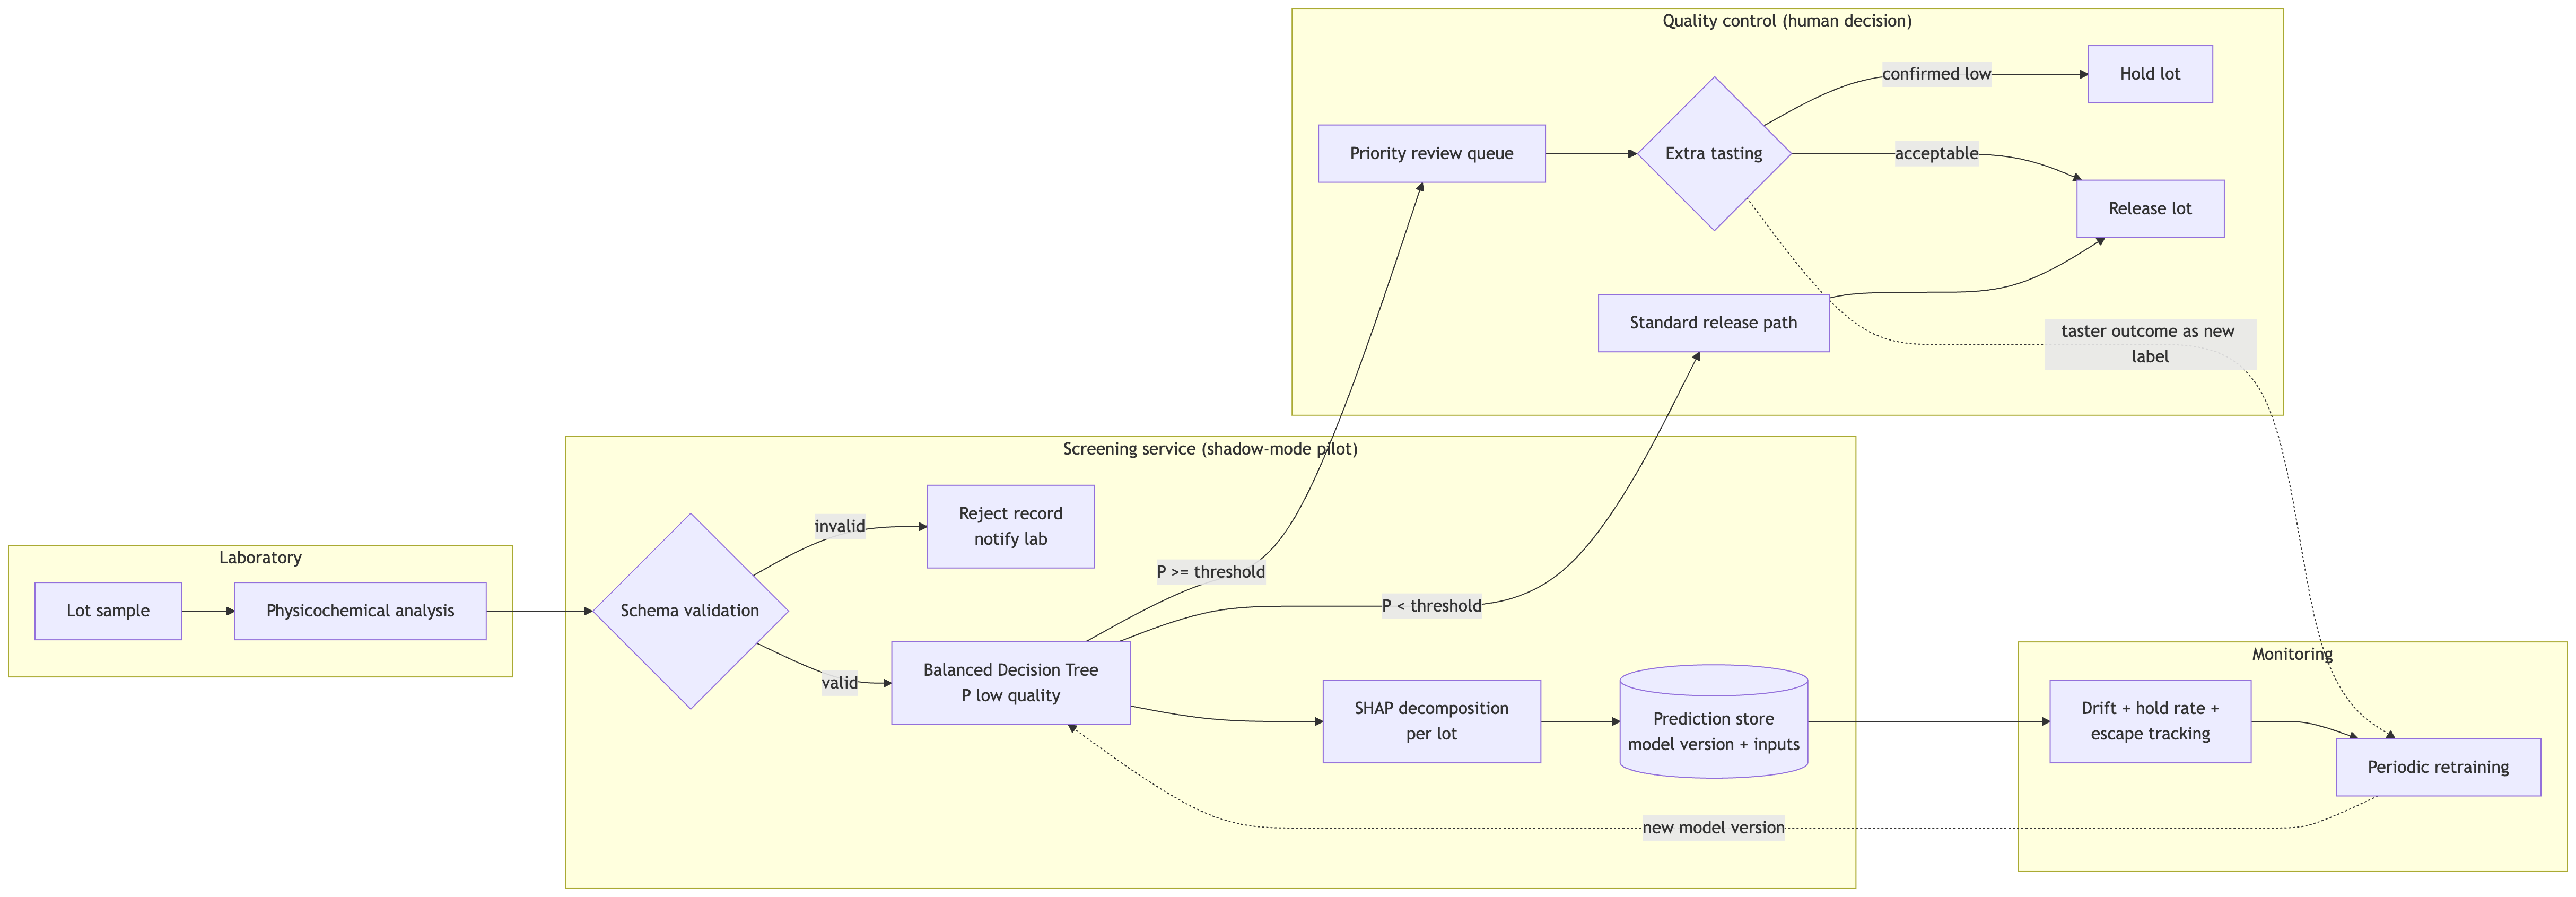

<details><summary>Diagram source (mermaid)</summary>

```mermaid
flowchart LR
    subgraph Laboratory
        A[Lot sample] --> B[Physicochemical analysis]
    end
    subgraph Screening["Screening service (shadow-mode pilot)"]
        B --> C{Schema validation}
        C -->|invalid| X[Reject record\nnotify lab]
        C -->|valid| D[Balanced Decision Tree\nP low quality]
        D --> E[SHAP decomposition\nper lot]
        E --> F[(Prediction store\nmodel version + inputs)]
    end
    subgraph QC["Quality control (human decision)"]
        D -->|P >= threshold| G[Priority review queue]
        D -->|P < threshold| H[Standard release path]
        G --> I{Extra tasting}
        I -->|confirmed low| J[Hold lot]
        I -->|acceptable| K[Release lot]
        H --> K
    end
    subgraph Monitoring
        F --> L[Drift + hold rate +\nescape tracking]
        I -.taster outcome as new label.-> M[Periodic retraining]
        L --> M
        M -.new model version.-> D
    end
```

</details>